# 🧪 Project Final Report

This is the final project report for CS6101. It is started as a copy of the `Project_Proposal.ipynb` template for consistency.


# Problem Statement
I am trying to predict the ReactivePower of a wind turbine farm as a function of the other features in the dataset. Some features are definitely also derivative features of the environment conditions, such as the aforementioned component temperatures. At a minimum, I want to utilize:
1. `WindSpeed` (Obviously, this is a wind turbine!)
2. `WindDirection` (Obviously, this is a wind turbine!) - This is probably more related to weather conditions, so if I include the time-of-day or day-of-year, I may see some other correlations
3. `AmbientTemperature` (I don't think this should be a physical relationship, but I wonder if based upon the location of the wind farm, warmer days are more windy?)
4. `BladePitchAngle` (this will be more important when the power output is 0)
5. `TurbineStatus` (this will be more important when the power output is 0)
6. The other variables are listed above, since the cutoff threshold was 0.85 correlation coefficient. Most of them, I think, are too closely related as internal derived parameters, so should be excluded.

**Label Columns:** `WTG`: This is the unique identifier for the wind turbine in the farm. Since there is only one turbine monitored, it has one value, and is therefore not a useful feature. It's not even really a label.

Here is the link to the [Kaggle Dataset](https://www.kaggle.com/datasets/theforcecoder/wind-power-forecasting).


## Environment Setup

In [3]:
# ⚠️ Do not modify this block.
# You are not allowed to import any modules other than the ones already included in this notebook.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

# Data Preprocessing - This comes from the proposal work
Because the proposal work already did most of the requirements, I am just copying it here, but reducing the number of cells for clarity. Here are the requirements which preprocessing must meet:
1. Load dataset using `gdown`
2. Remove missing values and extreme outliers
3. Clean and analyze regression label
4. Bin the label for classification - utilized `pdquant` to guarantee perfect bin level-cuts.
5. Encode categorical features - N/A in this dataset
6. Normalize numerical columns - additional work, separate cell at the bottom.

## Load the Data

> NOTE: This is taken directly from the Proposal notebook, but flattened into fewer cells with the instructions removed for clarity.

It also caches the .csv download for convenience, so the notebook can be rerun.

In [7]:
# Download the CSV file if it does not yet exist - caches between runs.
if 'turbine-data.csv' not in os.listdir():
    URL = "https://drive.google.com/file/d/1EA5TGwyZ4QYBocB4Q5s8rBNTdj2vkay8/view?usp=drive_link"
    gdown.download(id="1EA5TGwyZ4QYBocB4Q5s8rBNTdj2vkay8")
else:
    print("Data already cached, skipping download.")

raw_data = pd.read_csv('turbine-data.csv', index_col=0)
raw_data = raw_data.reset_index().rename(columns={'index': 'TimeStamp'})
# Remove columns that aren't relevant (eg metadata)
# ControlBoxTemperature has 2 values, WTG has 1.
raw_data = raw_data.drop(columns=['ControlBoxTemperature', 'WTG'])

# Convert timestamp to fractional hours of the day.
raw_data['TimeOfDay'] = pd.to_datetime(raw_data['TimeStamp']).dt.hour + pd.to_datetime(
    raw_data['TimeStamp']).dt.minute / 60
raw_data['DayOfYear'] = pd.to_datetime(raw_data['TimeStamp']).dt.dayofyear

# Drop all non-numeric columns
raw_data = raw_data.select_dtypes(include=[np.number]).copy()
# Dropping NA here to ensure enough rows.
raw_data = raw_data.dropna().copy()

### END SOLUTION
print("Number of rows:", raw_data.shape[0])
print("Number of columns:", raw_data.shape[1])


Data already cached, skipping download.
Number of rows: 32818
Number of columns: 21


## Label Cleanup
Since the invalid data was already removed: NaN, text fields, etc, the goal here is to show the valid raw data _before_ and _after_ extrema cleanup and balancing. For clarity, both will show a regular histogram, then the quantile level-cuts which will ensure class labels _are balanced by construction_.

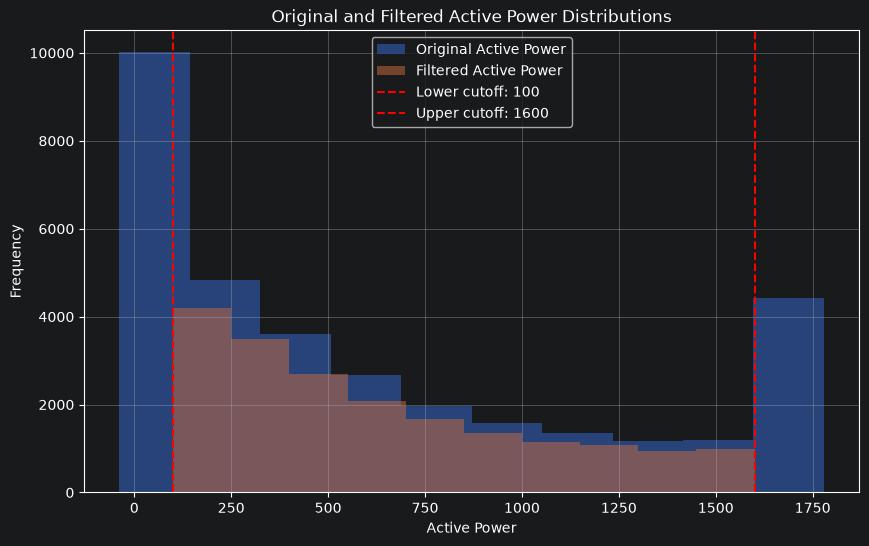

In [10]:
from sklearn.preprocessing import StandardScaler

label_name = 'ActivePower'
raw_data['Regression_Label'] = raw_data[label_name]

# Because the histogram is imbalanced with 0s, remove those - TODO - See if we can include those again!
lower_limit = 100
upper_limit = 1600  # There's a lot at ~1750

plt.figure(figsize=(10, 6))
raw_data['Regression_Label'].hist(alpha=0.5, label='Original Active Power')
filtered_data = raw_data[(raw_data['Regression_Label'] > lower_limit) & (raw_data['Regression_Label'] < upper_limit)].copy()
filtered_data['Regression_Label'].hist(alpha=0.5, label='Filtered Active Power')
plt.axvline(lower_limit, color='red', linestyle='--', label=f'Lower cutoff: {lower_limit}')
plt.axvline(upper_limit, color='red', linestyle='--', label=f'Upper cutoff: {upper_limit}')
plt.xlabel('Active Power')
plt.ylabel('Frequency')
plt.title('Original and Filtered Active Power Distributions')
plt.legend()
plt.show()

data = filtered_data
# This bonus column is used for regression fitting convenience.
data['SS_Regression_Label'] = data['Regression_Label']
numeric_cols = raw_data.select_dtypes(include=[np.number]).columns
feature_numeric_cols = [col for col in numeric_cols if
                        col not in [label_name, 'Regression_Label', 'Classification_Label']]
# NOW - Do the StandardScaler for clarity, we will inverse-transform at the end.
s = StandardScaler()
data[feature_numeric_cols] = s.fit_transform(data[feature_numeric_cols])

## Feature Selection and Extraction
This is here to remove correlated features, such as BladePitchAngle, which will be monitored on all 3 blades, but for physics reasons must be essentially the same. As the Correlation Matrix below shows, those features at correlated at unity.
Additional correlation findings which are understandable:
1. `NacellePosition` vs `WindDirection`: This also makes sense, since the most efficient orientation is facing into the wind.
2. `GeneratorRPM` vs `MotorRPM`: This is expected, since the generator and motor are directly connected.
3. `AmbientTemperature` vs `MainBoxTemperature`: This is expected, since the hub/nacelle temperature is closely related to the ambient temperature, as well as the other system component temperatures.
   - You can see this with the cluster of `GearboxBearingTemperature`, `GearboxOilTemperature`, `GeneratorWinding1Temperature`, `GeneratorWinding2Temperature`: These are all related components, and because of the metal and oil they will have very similar temperatures.

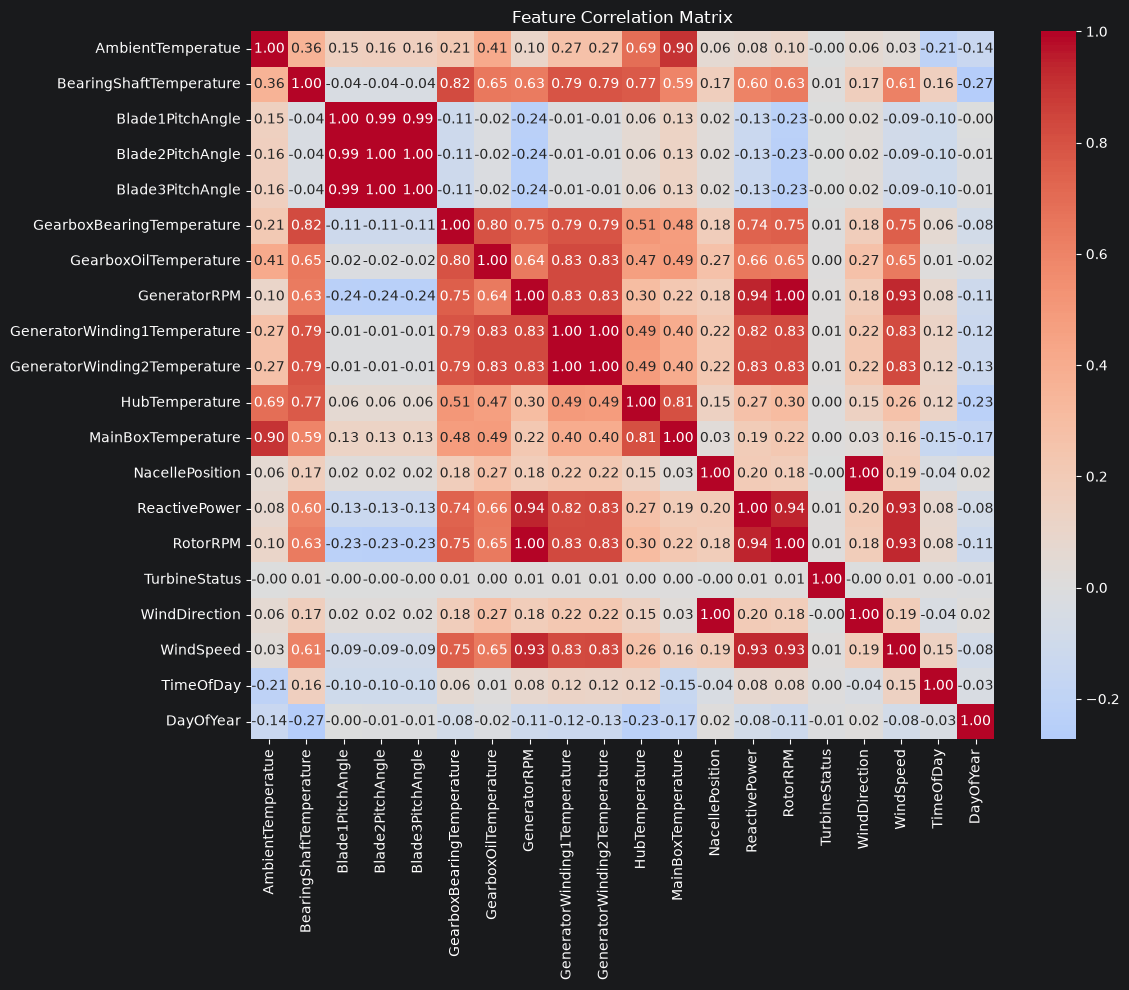

Removed features due to high correlation: ['MainBoxTemperature', 'Blade2PitchAngle', 'Blade3PitchAngle', 'ReactivePower', 'RotorRPM', 'WindSpeed', 'GeneratorWinding2Temperature', 'WindDirection']
Number of Features selected:  12 ['AmbientTemperatue', 'BearingShaftTemperature', 'Blade1PitchAngle', 'GearboxBearingTemperature', 'GearboxOilTemperature', 'GeneratorRPM', 'GeneratorWinding1Temperature', 'HubTemperature', 'NacellePosition', 'TurbineStatus', 'TimeOfDay', 'DayOfYear']


In [11]:
# Get all numeric features except the labels
feature_cols = [col for col in data.columns if col not in ['Regression_Label', 'Classification_Label', 'SS_Regression_Label', label_name]]
features_df = data[feature_cols]

# Calculate correlation matrix
corr_matrix = features_df.corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Identify highly correlated features (threshold of 0.85)
removed_features = []
correlation_threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname = corr_matrix.columns[j]
            if colname not in removed_features:
                removed_features.append(colname)

print(f"Removed features due to high correlation: {removed_features}")

# Create final feature set
final_features = [col for col in feature_cols if col not in removed_features]
X = data[final_features]
print("Number of Features selected: ", X.shape[1], final_features)


## Bin Classification Labels
Because classification is easier with balanced classes, and this dataset has a continuous range, I am using `pd.qcut()` to bin the continuous label into 5 equal-sized bins. This guarantees balanced classes by construction, at the cost of interpretable labels if the the dataset were not continuous (eg holes in the histogram above).

Bin boundaries for each label:
Label 0: [100, 240)
Label 1: [240, 406)
Label 2: [406, 646)
Label 3: [646, 1026)
Label 4: [1026, 1600)


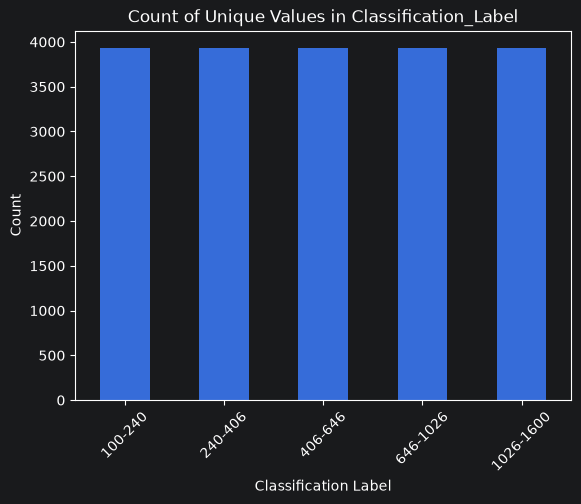

In [12]:
bins, labels = pd.qcut(data['Regression_Label'], q=5, retbins=True)
rounded_labels = np.rint(labels).astype(int)
bin_labels = [f"{rounded_labels[i]}-{rounded_labels[i + 1]}" for i in range(len(rounded_labels) - 1)]

print("Bin boundaries for each label:")
for i in range(len(labels) - 1):
    print(f"Label {i}: [{rounded_labels[i]}, {rounded_labels[i + 1]})")

data['Classification_Label'] = pd.qcut(data['Regression_Label'], q=5, labels=bin_labels)

#If you wrote the code above correctly, running the following block should generate a histogram of your discrete label.
#Do not change the code in this block.

data["Classification_Label"].value_counts().plot(kind='bar')

plt.xlabel("Classification Label")
plt.ylabel("Count")
plt.title("Count of Unique Values in Classification_Label")
plt.xticks(rotation=45)
plt.show()


## Comparing Supervised Learning Models
- As requested, I am training at least two regression models. `LinearRegression` is a requirement, and I will try a few others for comparison. One of my personal interests is in the time/quality tradeoff, so I will also be reporting them for comparison.
- As requested, I am training at least two classification models. `LogisticRegression` and `MLP >= 1 HL` are both required, and I will add others as well. `MDC` is noted as not allowed, but I am chosing to include it purely out of curiosity.

> On this dataset, is there a pareto front of quality/time?

In [14]:
# Some ancillary support functions used below:
from sklearn.model_selection import train_test_split

# TODO - Make this a proper jupyter progress bar? Keras?
def print_progress(current, total, label, bar_width=30):
    progress = current / total
    filled_width = int(bar_width * progress)
    bar = "█" * filled_width + "░" * (bar_width - filled_width)
    print(f"\r{label}: |{bar}| {current}/{total} ({progress:.0%})", end="", flush=True)
    if current == total:
        print()


# 4. Report the Pareto front of quality/time for each task.
def pareto_front(results_df, score_column, time_column="Train Seconds"):
    pareto_rows = []
    sorted_results = results_df.sort_values(
        by=[time_column, score_column],
        ascending=[True, False],
    ).reset_index(drop=True)

    best_score_so_far = -np.inf
    for _, row in sorted_results.iterrows():
        if row[score_column] > best_score_so_far:
            pareto_rows.append(row)
            best_score_so_far = row[score_column]

    return pd.DataFrame(pareto_rows).reset_index(drop=True)



# Repeatable experiment configuration
RANDOM_STATE = 6101
TEST_SIZE = 0.20
CV_FOLDS = 3
REGRESSION_TARGET_SCORE = 0.90
CLASSIFICATION_TARGET_SCORE = 0.90

# 1. Split the dataset once, using stratification from the classification label for repeatability.
y_regression = data["SS_Regression_Label"]
y_classification = data["Classification_Label"].astype(str)

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,
    y_regression,
    y_classification,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_classification,
)

In [15]:
from time import perf_counter

from scipy.optimize import differential_evolution
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

# 2. Select regression models and use differential evolution to find the fastest valid parameters.
regression_searches = {
    "LinearRegression": {
        "class": LinearRegression,
        "bounds": [(0, 1)],
        "vector_to_params": lambda x: {
            "fit_intercept": bool(int(round(x[0]))),
        },
    },
    "Ridge": {
        "class": Ridge,
        "bounds": [(0.0001, 100.0), (0, 1)],
        "vector_to_params": lambda x: {
            "alpha": float(x[0]),
            "fit_intercept": bool(int(round(x[1]))),
            "random_state": RANDOM_STATE,
        },
    },
    "RandomForestRegressor": {
        "class": RandomForestRegressor,
        "bounds": [(10, 200), (2, 30), (1, 10), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "max_depth": None if int(round(x[3])) == 1 else int(round(x[1])),
            "min_samples_leaf": int(round(x[2])),
            "bootstrap": bool(int(round(x[4]))),
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        },
    },
    "GradientBoostingRegressor": {
        "class": GradientBoostingRegressor,
        "bounds": [(10, 200), (0.01, 0.20), (1, 5), (1, 10), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "learning_rate": float(x[1]),
            "max_depth": int(round(x[2])),
            "min_samples_leaf": int(round(x[3])),
            "subsample": 0.75 if int(round(x[4])) == 1 else 1.0,
            "random_state": RANDOM_STATE,
        },
    },
    "MLPRegressor": {
        "class": MLPRegressor,
        "bounds": [(10, 100), (0, 75), (0.00001, 0.01), (0.0001, 0.05), (50, 500), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "hidden_layer_sizes": (
                (int(round(x[0])),)
                if int(round(x[5])) == 0
                else (int(round(x[0])), max(5, int(round(x[1]))))
            ),
            "alpha": float(x[2]),
            "learning_rate_init": float(x[3]),
            "max_iter": int(round(x[4])),
            "early_stopping": bool(int(round(x[6]))),
            "random_state": RANDOM_STATE,
        },
    },
}

regression_results = []

print_progress(0, len(regression_searches), "Regression differential evolution progress")
for model_index, (model_name, search_config) in enumerate(regression_searches.items(), start=1):
    print(f"\nOptimizing regression model {model_index}/{len(regression_searches)}: {model_name}")

    model_results = []


    def evaluate_regression_candidate(x):
        params = search_config["vector_to_params"](x)

        try:
            candidate_model = search_config["class"](**params)

            train_start_time = perf_counter()
            candidate_model.fit(X_train, y_reg_train)
            train_seconds = perf_counter() - train_start_time

            y_reg_pred = candidate_model.predict(X_test)
            test_r2 = r2_score(y_reg_test, y_reg_pred)
            test_mse = mean_squared_error(y_reg_test, y_reg_pred)
            test_mae = mean_absolute_error(y_reg_test, y_reg_pred)
        except Exception:
            return 1_000_000.0

        meets_target = test_r2 >= REGRESSION_TARGET_SCORE
        invalid_penalty = 0.0 if meets_target else 1_000_000.0 + (REGRESSION_TARGET_SCORE - test_r2) * 10_000.0
        numeric_size_penalty = sum(
            float(value)
            for value in params.values()
            if isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)
        ) * 1e-6
        optimizer_objective = invalid_penalty + train_seconds + numeric_size_penalty

        model_results.append({
            "Task": "Regression",
            "Model": model_name,
            "Test R2": test_r2,
            "R2": test_r2,
            "MSE": test_mse,
            "MAE": test_mae,
            "Train Seconds": train_seconds,
            "Meets Target": meets_target,
            "Best Params": params,
            "Best Estimator": candidate_model,
            "Optimizer Objective": optimizer_objective,
        })

        return optimizer_objective


    rng = np.random.default_rng(RANDOM_STATE + model_index)
    initial_population = rng.uniform(
        low=[bound[0] for bound in search_config["bounds"]],
        high=[bound[1] for bound in search_config["bounds"]],
        size=(max(8, 2 * len(search_config["bounds"])), len(search_config["bounds"])),
    )

    optimization_start_time = perf_counter()
    differential_evolution(
        evaluate_regression_candidate,
        bounds=search_config["bounds"],
        seed=RANDOM_STATE + model_index,
        maxiter=6,
        popsize=4,
        init=initial_population,
        polish=False,
        updating="immediate",
        workers=1,
        tol=0.01,
    )
    optimizer_seconds = perf_counter() - optimization_start_time

    valid_model_results = [result for result in model_results if result["Meets Target"]]
    if valid_model_results:
        best_result = min(valid_model_results, key=lambda result: result["Train Seconds"])
    elif model_results:
        best_result = max(model_results, key=lambda result: result["Test R2"])
    else:
        best_result = {
            "Task": "Regression",
            "Model": model_name,
            "CV Best R2": np.nan,
            "Test R2": np.nan,
            "R2": np.nan,
            "MSE": np.nan,
            "MAE": np.nan,
            "Train Seconds": np.nan,
            "Meets Target": False,
            "Best Params": {},
            "Best Estimator": None,
            "Optimizer Objective": np.nan,
        }

    best_result["Optimizer Seconds"] = optimizer_seconds
    best_result["Candidate Count"] = len(model_results)
    regression_results.append(best_result)

    print_progress(model_index, len(regression_searches), "Regression differential evolution progress")

regression_results_df = pd.DataFrame(regression_results).sort_values(
    by=["Meets Target", "Train Seconds", "Test R2"],
    ascending=[False, True, False],
).reset_index(drop=True)


Regression differential evolution progress: |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 0/6 (0%)
Optimizing regression model 1/6: DummyRegressor
Regression differential evolution progress: |█████░░░░░░░░░░░░░░░░░░░░░░░░░| 1/6 (17%)
Optimizing regression model 2/6: LinearRegression
Regression differential evolution progress: |██████████░░░░░░░░░░░░░░░░░░░░| 2/6 (33%)
Optimizing regression model 3/6: Ridge
Regression differential evolution progress: |███████████████░░░░░░░░░░░░░░░| 3/6 (50%)
Optimizing regression model 4/6: RandomForestRegressor
Regression differential evolution progress: |████████████████████░░░░░░░░░░| 4/6 (67%)
Optimizing regression model 5/6: GradientBoostingRegressor
Regression differential evolution progress: |█████████████████████████░░░░░| 5/6 (83%)
Optimizing regression model 6/6: MLPRegressor


C:\personal\grad-school\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (99) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\personal\grad-school\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (65) reached and the optimization hasn't converged yet.
  warnings.warn(


Regression differential evolution progress: |██████████████████████████████| 6/6 (100%)


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.neural_network import MLPClassifier

# 3. Select classification models and use differential evolution to optimize F1, precision,
#    recall, and accuracy while minimizing operational time subject to target accuracy.
classification_searches = {
    "LogisticRegression": {
        "class": LogisticRegression,
        "bounds": [(0.001, 10.0), (100, 1000), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "C": float(x[0]),
            "max_iter": int(round(x[1])),
            "fit_intercept": bool(int(round(x[2]))),
            "class_weight": "balanced" if int(round(x[3])) == 1 else None,
            "solver": "lbfgs",
            "random_state": RANDOM_STATE,
        },
    },
    "RandomForestClassifier": {
        "class": RandomForestClassifier,
        "bounds": [(10, 200), (2, 30), (1, 10), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "max_depth": None if int(round(x[3])) == 1 else int(round(x[1])),
            "min_samples_leaf": int(round(x[2])),
            "bootstrap": bool(int(round(x[4]))),
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        },
    },
    "GradientBoostingClassifier": {
        "class": GradientBoostingClassifier,
        "bounds": [(10, 200), (0.01, 0.20), (1, 5), (1, 10), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "learning_rate": float(x[1]),
            "max_depth": int(round(x[2])),
            "min_samples_leaf": int(round(x[3])),
            "subsample": 0.75 if int(round(x[4])) == 1 else 1.0,
            "random_state": RANDOM_STATE,
        },
    },
    "MLPClassifier": {
        "class": MLPClassifier,
        "bounds": [(10, 100), (0, 75), (0.00001, 0.01), (0.0001, 0.05), (50, 500), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "hidden_layer_sizes": (
                (int(round(x[0])),)
                if int(round(x[5])) == 0
                else (int(round(x[0])), max(5, int(round(x[1]))))
            ),
            "alpha": float(x[2]),
            "learning_rate_init": float(x[3]),
            "max_iter": int(round(x[4])),
            "early_stopping": bool(int(round(x[6]))),
            "random_state": RANDOM_STATE,
        },
    },
}

classification_results = []

print_progress(0, len(classification_searches), "Classification differential evolution progress")
for model_index, (model_name, search_config) in enumerate(classification_searches.items(), start=1):
    print(f"\nOptimizing classification model {model_index}/{len(classification_searches)}: {model_name}")

    model_results = []


    def evaluate_classification_candidate(x):
        params = search_config["vector_to_params"](x)

        try:
            candidate_model = search_config["class"](**params)

            operation_start_time = perf_counter()
            candidate_model.fit(X_train, y_cls_train)
            y_cls_pred = candidate_model.predict(X_test)
            operation_seconds = perf_counter() - operation_start_time

            candidate_accuracy = accuracy_score(y_cls_test, y_cls_pred)
            candidate_f1 = f1_score(y_cls_test, y_cls_pred, average="weighted", zero_division=0)
            candidate_precision = precision_score(y_cls_test, y_cls_pred, average="weighted", zero_division=0)
            candidate_recall = recall_score(y_cls_test, y_cls_pred, average="weighted", zero_division=0)
        except Exception:
            return 1_000_000.0

        meets_target = candidate_accuracy >= CLASSIFICATION_TARGET_SCORE
        combined_metric_score = np.mean([
            candidate_f1,
            candidate_precision,
            candidate_recall,
            candidate_accuracy,
        ])

        invalid_penalty = (
            0.0
            if meets_target
            else 1_000_000.0 + (CLASSIFICATION_TARGET_SCORE - candidate_accuracy) * 10_000.0
        )
        numeric_size_penalty = sum(
            float(value)
            for value in params.values()
            if isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)
        ) * 1e-6
        optimizer_objective = invalid_penalty + operation_seconds - combined_metric_score + numeric_size_penalty

        model_results.append({
            "Task": "Classification",
            "Model": model_name,
            "CV Best Accuracy": np.nan,
            "Test Accuracy": candidate_accuracy,
            "F1": candidate_f1,
            "Precision": candidate_precision,
            "Recall": candidate_recall,
            "Train Seconds": operation_seconds,
            "Operational Seconds": operation_seconds,
            "Meets Target": meets_target,
            "Best Params": params,
            "Best Estimator": candidate_model,
            "Optimizer Objective": optimizer_objective,
        })

        return optimizer_objective


    rng = np.random.default_rng(RANDOM_STATE + model_index)
    initial_population = rng.uniform(
        low=[bound[0] for bound in search_config["bounds"]],
        high=[bound[1] for bound in search_config["bounds"]],
        size=(max(8, 2 * len(search_config["bounds"])), len(search_config["bounds"])),
    )

    optimization_start_time = perf_counter()
    differential_evolution(
        evaluate_classification_candidate,
        bounds=search_config["bounds"],
        seed=RANDOM_STATE + model_index,
        maxiter=6,
        popsize=4,
        init=initial_population,
        polish=False,
        updating="immediate",
        workers=1,
        tol=0.01,
    )
    optimizer_seconds = perf_counter() - optimization_start_time

    valid_model_results = [result for result in model_results if result["Meets Target"]]
    if valid_model_results:
        best_result = min(valid_model_results, key=lambda result: result["Optimizer Objective"])
    elif model_results:
        best_result = max(
            model_results,
            key=lambda result: (
                result["Test Accuracy"],
                result["F1"],
                result["Precision"],
                result["Recall"],
                -result["Operational Seconds"],
            ),
        )
    else:
        best_result = {
            "Task": "Classification",
            "Model": model_name,
            "CV Best Accuracy": np.nan,
            "Test Accuracy": np.nan,
            "F1": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "Train Seconds": np.nan,
            "Operational Seconds": np.nan,
            "Meets Target": False,
            "Best Params": {},
            "Best Estimator": None,
            "Optimizer Objective": np.nan,
        }

    best_result["Optimizer Seconds"] = optimizer_seconds
    best_result["Candidate Count"] = len(model_results)
    classification_results.append(best_result)

    print_progress(model_index, len(classification_searches), "Classification differential evolution progress")

classification_results_df = pd.DataFrame(classification_results).sort_values(
    by=["Meets Target", "Test Accuracy", "F1", "Precision", "Recall", "Operational Seconds"],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)


Classification differential evolution progress: |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 0/4 (0%)
Optimizing classification model 1/4: LogisticRegression


C:\personal\grad-school\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 128 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=128).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification differential evolution progress: |███████░░░░░░░░░░░░░░░░░░░░░░░| 1/4 (25%)
Optimizing classification model 2/4: RandomForestClassifier
Classification differential evolution progress: |███████████████░░░░░░░░░░░░░░░| 2/4 (50%)
Optimizing classification model 3/4: GradientBoostingClassifier


In [ ]:
regression_results_for_pareto_df = regression_results_df.copy()
regression_results_for_pareto_df["Negative MSE"] = -regression_results_for_pareto_df["MSE"]

regression_pareto_front_df = pareto_front(regression_results_for_pareto_df, "Negative MSE").drop(
    columns=["Negative MSE"]
)
classification_pareto_front_df = pareto_front(classification_results_df, "F1")

best_regression_model = regression_results_df.sort_values(
    by=["MSE", "Train Seconds"],
    ascending=[True, True],
).iloc[0]
best_classification_model = classification_results_df.sort_values(
    by=["F1", "Train Seconds"],
    ascending=[False, True],
).iloc[0]

optimal_regressor = best_regression_model["Best Estimator"]
optimal_regressor_params = best_regression_model["Best Params"]
optimal_classifier = best_classification_model["Best Estimator"]
optimal_classifier_params = best_classification_model["Best Params"]

print("Regression results, sorted by lowest test MSE:")
display(
    regression_results_df.sort_values(
        by=["MSE", "Train Seconds"],
        ascending=[True, True],
    ).drop(columns=["Best Estimator"])
)

print("Regression Pareto front, minimizing MSE while minimizing single-model training time:")
display(regression_pareto_front_df.drop(columns=["Best Estimator"]))

plt.figure(figsize=(10, 6))
plt.scatter(
    regression_results_df["Train Seconds"],
    regression_results_df["MSE"],
    label="All regression models",
    alpha=0.75,
)

regression_pareto_plot_df = regression_pareto_front_df.sort_values("Train Seconds")
plt.plot(
    regression_pareto_plot_df["Train Seconds"],
    regression_pareto_plot_df["MSE"],
    marker="o",
    linewidth=2,
    color="red",
    label="Pareto front",
)

for _, row in regression_results_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Train Seconds"], row["MSE"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

plt.xlabel("Single-model training time after best parameters found (seconds)")
plt.ylabel("Test MSE")
plt.title("Regression Pareto Front: Model Training Time vs MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal regression model:")
print(f"Model: {best_regression_model['Model']}")
print(f"Test MSE: {best_regression_model['MSE']:.4f}")
print(f"Test R2: {best_regression_model['Test R2']:.4f}")
print(f"Meets target R2 >= {REGRESSION_TARGET_SCORE}: {best_regression_model['Meets Target']}")
print(f"Best parameters: {optimal_regressor_params}")

print("\nClassification results, sorted by best F1:")
display(
    classification_results_df.sort_values(
        by=["F1", "Train Seconds"],
        ascending=[False, True],
    ).drop(columns=["Best Estimator"])
)

print("Classification Pareto front, maximizing F1 while minimizing single-model training time:")
display(classification_pareto_front_df.drop(columns=["Best Estimator"]))

plt.figure(figsize=(10, 6))
plt.scatter(
    classification_results_df["Train Seconds"],
    classification_results_df["F1"],
    label="All classification models",
    alpha=0.75,
)

classification_pareto_plot_df = classification_pareto_front_df.sort_values("Train Seconds")
plt.plot(
    classification_pareto_plot_df["Train Seconds"],
    classification_pareto_plot_df["F1"],
    marker="o",
    linewidth=2,
    color="red",
    label="Pareto front",
)

for _, row in classification_results_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Train Seconds"], row["F1"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

plt.xlabel("Single-model training time after best parameters found (seconds)")
plt.ylabel("Weighted F1")
plt.title("Classification Pareto Front: Model Training Time vs F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal classification model:")
print(f"Model: {best_classification_model['Model']}")
print(f"F1: {best_classification_model['F1']:.4f}")
print(f"Test Accuracy: {best_classification_model['Test Accuracy']:.4f}")
print(f"Meets target accuracy >= {CLASSIFICATION_TARGET_SCORE}: {best_classification_model['Meets Target']}")
print(f"Best parameters: {optimal_classifier_params}")


`DummyClassifier` is included for the LOLs, not because I expect it to do well. It's clearly the outlier in the pareto-front at about 20% accuracy, so I won't include it in the differential evolution search.

Now that we have a pareto-front list of candidate models, I want to use differential evolution to find the smallest/fastest-training model of each type that meets the target accuracy. These limited model selections will be the ones where I report the other parameters.

In [44]:
# 1. Down-select to the models which _actually_ got to the required accuracy cutoff.
classification_results_df = classification_results_df[classification_results_df["Meets Target"] == True].copy()

# 2. Use a scipy-style randomized optimizer search, seeded from the current best models,
#    to shrink numeric parameters and toggle flags while excluding sub-target results.
from scipy.optimize import differential_evolution
from sklearn.base import clone

classification_optimizer_results = []

optimizer_model_specs = {
    "RandomForestClassifier": {
        "class": RandomForestClassifier,
        "bounds": [(10, 200), (2, 30), (1, 10), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "max_depth": None if int(round(x[3])) == 1 else int(round(x[1])),
            "min_samples_leaf": int(round(x[2])),
            "bootstrap": bool(int(round(x[4]))),
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        },
        "params_to_vector": lambda p: np.array([
            p.get("n_estimators", 100),
            30 if p.get("max_depth", None) is None else p.get("max_depth", 12),
            p.get("min_samples_leaf", 1),
            1 if p.get("max_depth", None) is None else 0,
            1 if p.get("bootstrap", True) else 0,
        ], dtype=float),
    },
    "GradientBoostingClassifier": {
        "class": GradientBoostingClassifier,
        "bounds": [(10, 200), (0.01, 0.20), (1, 5), (1, 10), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "learning_rate": float(x[1]),
            "max_depth": int(round(x[2])),
            "min_samples_leaf": int(round(x[3])),
            "subsample": 0.75 if int(round(x[4])) == 1 else 1.0,
            "random_state": RANDOM_STATE,
        },
        "params_to_vector": lambda p: np.array([
            p.get("n_estimators", 100),
            p.get("learning_rate", 0.10),
            p.get("max_depth", 3),
            p.get("min_samples_leaf", 1),
            1 if p.get("subsample", 1.0) < 1.0 else 0,
        ], dtype=float),
    },
    "MLPClassifier": {
        "class": MLPClassifier,
        "bounds": [(10, 100), (0, 75), (0.00001, 0.01), (0.0001, 0.05), (50, 500), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "hidden_layer_sizes": (
                (int(round(x[0])),)
                if int(round(x[5])) == 0
                else (int(round(x[0])), max(5, int(round(x[1]))))
            ),
            "alpha": float(x[2]),
            "learning_rate_init": float(x[3]),
            "max_iter": int(round(x[4])),
            "early_stopping": bool(int(round(x[6]))),
            "random_state": RANDOM_STATE,
        },
        "params_to_vector": lambda p: np.array([
            p.get("hidden_layer_sizes", (50,))[0],
            p.get("hidden_layer_sizes", (50, 0))[1] if len(p.get("hidden_layer_sizes", (50,))) > 1 else 0,
            p.get("alpha", 0.0001),
            p.get("learning_rate_init", 0.001),
            p.get("max_iter", 500),
            1 if len(p.get("hidden_layer_sizes", (50,))) > 1 else 0,
            1 if p.get("early_stopping", True) else 0,
        ], dtype=float),
    },
    "LogisticRegression": {
        "class": LogisticRegression,
        "bounds": [(0.001, 10.0), (50, 1000), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "C": float(x[0]),
            "max_iter": int(round(x[1])),
            "fit_intercept": bool(int(round(x[2]))),
            "class_weight": "balanced" if int(round(x[3])) == 1 else None,
            "solver": "lbfgs",
            "random_state": RANDOM_STATE,
        },
        "params_to_vector": lambda p: np.array([
            p.get("C", 1.0),
            p.get("max_iter", 1000),
            1 if p.get("fit_intercept", True) else 0,
            1 if p.get("class_weight", None) == "balanced" else 0,
        ], dtype=float),
    },
}

eligible_rows = [
    row for _, row in classification_results_df.iterrows()
    if row["Model"] in optimizer_model_specs and row["Model"] != "DummyClassifier"
]

print_progress(0, len(eligible_rows), "Classification optimizer progress")
for model_index, current_best_row in enumerate(eligible_rows, start=1):
    model_name = current_best_row["Model"]
    spec = optimizer_model_specs[model_name]
    current_params = dict(current_best_row["Best Params"])
    current_estimator = current_best_row["Best Estimator"]
    current_estimator_params = current_estimator.get_params()
    current_params.update({
        key: value
        for key, value in current_estimator_params.items()
        if key in spec["class"]().get_params()
    })

    candidate_results = []


    def evaluate_candidate(x):
        params = spec["vector_to_params"](x)
        try:
            candidate_model = spec["class"](**params)
            train_start_time = perf_counter()
            candidate_model.fit(X_train, y_cls_train)
            candidate_train_seconds = perf_counter() - train_start_time
            candidate_accuracy = accuracy_score(y_cls_test, candidate_model.predict(X_test))
        except Exception:
            return 1_000_000.0

        if candidate_accuracy < CLASSIFICATION_TARGET_SCORE:
            return 1_000_000.0 + (CLASSIFICATION_TARGET_SCORE - candidate_accuracy) * 10_000.0

        numeric_size_penalty = sum(
            float(value)
            for value in params.values()
            if isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)
        ) * 1e-6

        candidate_results.append({
            "Task": "Classification",
            "Model": model_name,
            "CV Best Accuracy": np.nan,
            "Test Accuracy": candidate_accuracy,
            "Train Seconds": candidate_train_seconds,
            "Meets Target": True,
            "Best Params": params,
            "Best Estimator": candidate_model,
            "Optimizer Objective": candidate_train_seconds + numeric_size_penalty,
        })
        return candidate_train_seconds + numeric_size_penalty


    x0 = spec["params_to_vector"](current_params)
    initial_population = np.random.default_rng(RANDOM_STATE + model_index).uniform(
        low=[bound[0] for bound in spec["bounds"]],
        high=[bound[1] for bound in spec["bounds"]],
        size=(max(8, 2 * len(spec["bounds"])), len(spec["bounds"])),
    )
    initial_population[0, :] = np.clip(
        x0,
        [bound[0] for bound in spec["bounds"]],
        [bound[1] for bound in spec["bounds"]],
    )

    differential_evolution(
        evaluate_candidate,
        bounds=spec["bounds"],
        seed=RANDOM_STATE + model_index,
        maxiter=6,
        popsize=4,
        init=initial_population,
        polish=False,
        updating="immediate",
        workers=1,
        tol=0.01,
    )

    if candidate_results:
        best_candidate = min(candidate_results, key=lambda result: result["Optimizer Objective"])
        classification_optimizer_results.append(best_candidate)

    print_progress(model_index, len(eligible_rows), "Classification optimizer progress")

classification_optimizer_results_df = pd.DataFrame(classification_optimizer_results)

if not classification_optimizer_results_df.empty:
    classification_optimizer_results_df = classification_optimizer_results_df.sort_values(
        by=["Train Seconds", "Test Accuracy"],
        ascending=[True, False],
    ).reset_index(drop=True)

    classification_results_df = pd.concat(
        [classification_results_df, classification_optimizer_results_df[classification_results_df.columns]],
        ignore_index=True,
    ).sort_values(
        by=["Test Accuracy", "Train Seconds"],
        ascending=[False, True],
    ).reset_index(drop=True)

display(classification_optimizer_results_df.drop(columns=["Best Estimator"], errors="ignore"))


Classification optimizer progress: |████████████████████░░░░░░░░░░| 2/3 (67%)

C:\personal\grad-school\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (66) reached and the optimization hasn't converged yet.
  warnings.warn(


Classification optimizer progress: |██████████████████████████████| 3/3 (100%)


,Task,Model,CV Best Accuracy,Test Accuracy,Train Seconds,Meets Target,Best Params,Optimizer Objective
0,Classification,RandomForestClassifier,NaN,0.937166,0.053294,True,"{'n_estimators': 10, 'max_depth': 7, 'min_samp...",0.059417
1,Classification,MLPClassifier,NaN,0.932842,0.213758,True,"{'hidden_layer_sizes': (19,), 'alpha': 0.00124...",0.220070
2,Classification,GradientBoostingClassifier,NaN,0.922412,0.365826,True,"{'n_estimators': 11, 'learning_rate': 0.078413...",0.371949


Based upon a cached run, `RandomForestClassifier` is the best estimator. This is unsurprising. Random Forests are usually excellent. I'll stick with RandomForest from here on out for classification. Now let's do regression.

In [45]:
# 1. Down-select to the models which _actually_ got to the required accuracy cutoff.
regression_results_df = regression_results_df[regression_results_df["Meets Target"] == True].copy()

# 2. Use differential evolution to find the smallest / fastest-training regression model
#    which still satisfies the required test R2 threshold.
regression_optimizer_results = []

regression_optimizer_model_specs = {
    "RandomForestRegressor": {
        "class": RandomForestRegressor,
        "bounds": [(10, 200), (2, 30), (1, 10), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "max_depth": None if int(round(x[3])) == 1 else int(round(x[1])),
            "min_samples_leaf": int(round(x[2])),
            "bootstrap": bool(int(round(x[4]))),
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        },
        "params_to_vector": lambda p: np.array([
            p.get("n_estimators", 100),
            30 if p.get("max_depth", None) is None else p.get("max_depth", 12),
            p.get("min_samples_leaf", 1),
            1 if p.get("max_depth", None) is None else 0,
            1 if p.get("bootstrap", True) else 0,
        ], dtype=float),
    },
    "GradientBoostingRegressor": {
        "class": GradientBoostingRegressor,
        "bounds": [(10, 200), (0.01, 0.20), (1, 5), (1, 10), (0, 1)],
        "vector_to_params": lambda x: {
            "n_estimators": int(round(x[0])),
            "learning_rate": float(x[1]),
            "max_depth": int(round(x[2])),
            "min_samples_leaf": int(round(x[3])),
            "subsample": 0.75 if int(round(x[4])) == 1 else 1.0,
            "random_state": RANDOM_STATE,
        },
        "params_to_vector": lambda p: np.array([
            p.get("n_estimators", 100),
            p.get("learning_rate", 0.10),
            p.get("max_depth", 3),
            p.get("min_samples_leaf", 1),
            1 if p.get("subsample", 1.0) < 1.0 else 0,
        ], dtype=float),
    },
    "MLPRegressor": {
        "class": MLPRegressor,
        "bounds": [(10, 100), (0, 75), (0.00001, 0.01), (0.0001, 0.05), (50, 500), (0, 1), (0, 1)],
        "vector_to_params": lambda x: {
            "hidden_layer_sizes": (
                (int(round(x[0])),)
                if int(round(x[5])) == 0
                else (int(round(x[0])), max(5, int(round(x[1]))))
            ),
            "alpha": float(x[2]),
            "learning_rate_init": float(x[3]),
            "max_iter": int(round(x[4])),
            "early_stopping": bool(int(round(x[6]))),
            "random_state": RANDOM_STATE,
        },
        "params_to_vector": lambda p: np.array([
            p.get("hidden_layer_sizes", (50,))[0],
            p.get("hidden_layer_sizes", (50, 0))[1] if len(p.get("hidden_layer_sizes", (50,))) > 1 else 0,
            p.get("alpha", 0.0001),
            p.get("learning_rate_init", 0.001),
            p.get("max_iter", 500),
            1 if len(p.get("hidden_layer_sizes", (50,))) > 1 else 0,
            1 if p.get("early_stopping", True) else 0,
        ], dtype=float),
    },
    "Ridge": {
        "class": Ridge,
        "bounds": [(0.0001, 100.0), (0, 1)],
        "vector_to_params": lambda x: {
            "alpha": float(x[0]),
            "fit_intercept": bool(int(round(x[1]))),
            "random_state": RANDOM_STATE,
        },
        "params_to_vector": lambda p: np.array([
            p.get("alpha", 1.0),
            1 if p.get("fit_intercept", True) else 0,
        ], dtype=float),
    },
    "LinearRegression": {
        "class": LinearRegression,
        "bounds": [(0, 1)],
        "vector_to_params": lambda x: {
            "fit_intercept": bool(int(round(x[0]))),
        },
        "params_to_vector": lambda p: np.array([
            1 if p.get("fit_intercept", True) else 0,
        ], dtype=float),
    },
}

eligible_regression_rows = [
    row for _, row in regression_results_df.iterrows()
    if row["Model"] in regression_optimizer_model_specs and row["Model"] != "DummyRegressor"
]

print_progress(0, len(eligible_regression_rows), "Regression optimizer progress")
for model_index, current_best_row in enumerate(eligible_regression_rows, start=1):
    model_name = current_best_row["Model"]
    spec = regression_optimizer_model_specs[model_name]
    current_params = dict(current_best_row["Best Params"])
    current_estimator = current_best_row["Best Estimator"]
    current_estimator_params = current_estimator.get_params()
    current_params.update({
        key: value
        for key, value in current_estimator_params.items()
        if key in spec["class"]().get_params()
    })

    candidate_results = []


    def evaluate_regression_candidate(x):
        params = spec["vector_to_params"](x)
        try:
            candidate_model = spec["class"](**params)
            train_start_time = perf_counter()
            candidate_model.fit(X_train, y_reg_train)
            candidate_train_seconds = perf_counter() - train_start_time
            candidate_r2 = r2_score(y_reg_test, candidate_model.predict(X_test))
        except Exception:
            return 1_000_000.0

        if candidate_r2 < REGRESSION_TARGET_SCORE:
            return 1_000_000.0 + (REGRESSION_TARGET_SCORE - candidate_r2) * 10_000.0

        numeric_size_penalty = sum(
            float(value)
            for value in params.values()
            if isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)
        ) * 1e-6

        candidate_results.append({
            "Task": "Regression",
            "Model": model_name,
            "CV Best R2": np.nan,
            "Test R2": candidate_r2,
            "Train Seconds": candidate_train_seconds,
            "Meets Target": True,
            "Best Params": params,
            "Best Estimator": candidate_model,
            "Optimizer Objective": candidate_train_seconds + numeric_size_penalty,
        })
        return candidate_train_seconds + numeric_size_penalty


    x0 = spec["params_to_vector"](current_params)
    initial_population = np.random.default_rng(RANDOM_STATE + model_index + 100).uniform(
        low=[bound[0] for bound in spec["bounds"]],
        high=[bound[1] for bound in spec["bounds"]],
        size=(max(8, 2 * len(spec["bounds"])), len(spec["bounds"])),
    )
    initial_population[0, :] = np.clip(
        x0,
        [bound[0] for bound in spec["bounds"]],
        [bound[1] for bound in spec["bounds"]],
    )

    differential_evolution(
        evaluate_regression_candidate,
        bounds=spec["bounds"],
        seed=RANDOM_STATE + model_index + 100,
        maxiter=6,
        popsize=4,
        init=initial_population,
        polish=False,
        updating="immediate",
        workers=1,
        tol=0.01,
    )

    if candidate_results:
        best_candidate = min(candidate_results, key=lambda result: result["Optimizer Objective"])
        regression_optimizer_results.append(best_candidate)

    print_progress(model_index, len(eligible_regression_rows), "Regression optimizer progress")

regression_optimizer_results_df = pd.DataFrame(regression_optimizer_results)

if not regression_optimizer_results_df.empty:
    regression_optimizer_results_df = regression_optimizer_results_df.sort_values(
        by=["Train Seconds", "Test R2"],
        ascending=[True, False],
    ).reset_index(drop=True)

    regression_results_df = pd.concat(
        [regression_results_df, regression_optimizer_results_df[regression_results_df.columns]],
        ignore_index=True,
    ).sort_values(
        by=["Test R2", "Train Seconds"],
        ascending=[False, True],
    ).reset_index(drop=True)

display(regression_optimizer_results_df.drop(columns=["Best Estimator"], errors="ignore"))


Regression optimizer progress: |███████████████░░░░░░░░░░░░░░░| 2/4 (50%)

C:\personal\grad-school\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\personal\grad-school\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (441) reached and the optimization hasn't converged yet.
  warnings.warn(


Regression optimizer progress: |██████████████████████████████| 4/4 (100%)


,Task,Model,CV Best R2,Test R2,Train Seconds,Meets Target,Best Params,Optimizer Objective
0,Regression,Ridge,NaN,0.979830,0.001370,True,"{'alpha': 37.413418894702744, 'fit_intercept':...",0.007509
1,Regression,RandomForestRegressor,NaN,0.978017,0.040182,True,"{'n_estimators': 15, 'max_depth': 3, 'min_samp...",0.046305
2,Regression,GradientBoostingRegressor,NaN,0.986609,0.262170,True,"{'n_estimators': 21, 'learning_rate': 0.137036...",0.268302
3,Regression,MLPRegressor,NaN,0.988330,0.266518,True,"{'hidden_layer_sizes': (13, 12), 'alpha': 0.00...",0.273061


Regression model statistics:


,Task,Model,MSE,MAE,R2,Train Seconds,Best Params
0,Regression,RandomForestRegressor,1056.717580,18.744570,0.993980,0.961485,"{'max_depth': 24, 'min_samples_leaf': 1, 'n_es..."
1,Regression,GradientBoostingRegressor,1134.643705,18.800709,0.993537,4.549806,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
2,Regression,MLPRegressor,1694.362346,20.281449,0.990348,0.605092,"{'alpha': 0.001, 'hidden_layer_sizes': (50, 25..."
3,Regression,MLPRegressor,2048.644380,19.979055,0.988330,0.266518,"{'hidden_layer_sizes': (13, 12), 'alpha': 0.00..."
4,Regression,GradientBoostingRegressor,2350.833238,33.415023,0.986609,0.262170,"{'n_estimators': 21, 'learning_rate': 0.137036..."
5,Regression,Ridge,3540.830494,43.077901,0.979830,0.001370,"{'alpha': 37.413418894702744, 'fit_intercept':..."
6,Regression,Ridge,3579.828875,43.192989,0.979608,0.001799,"{'alpha': 1.0, 'fit_intercept': True}"
7,Regression,RandomForestRegressor,3859.050805,48.349472,0.978017,0.040182,"{'n_estimators': 15, 'max_depth': 3, 'min_samp..."


Regression statistics Pareto front, maximizing R2 while minimizing single-model training time:


,Task,Model,MSE,MAE,R2,Train Seconds,Best Params
0,Regression,Ridge,3540.830494,43.077901,0.979830,0.001370,"{'alpha': 37.413418894702744, 'fit_intercept':..."
1,Regression,GradientBoostingRegressor,2350.833238,33.415023,0.986609,0.262170,"{'n_estimators': 21, 'learning_rate': 0.137036..."
2,Regression,MLPRegressor,2048.644380,19.979055,0.988330,0.266518,"{'hidden_layer_sizes': (13, 12), 'alpha': 0.00..."
3,Regression,MLPRegressor,1694.362346,20.281449,0.990348,0.605092,"{'alpha': 0.001, 'hidden_layer_sizes': (50, 25..."
4,Regression,RandomForestRegressor,1056.717580,18.744570,0.993980,0.961485,"{'max_depth': 24, 'min_samples_leaf': 1, 'n_es..."


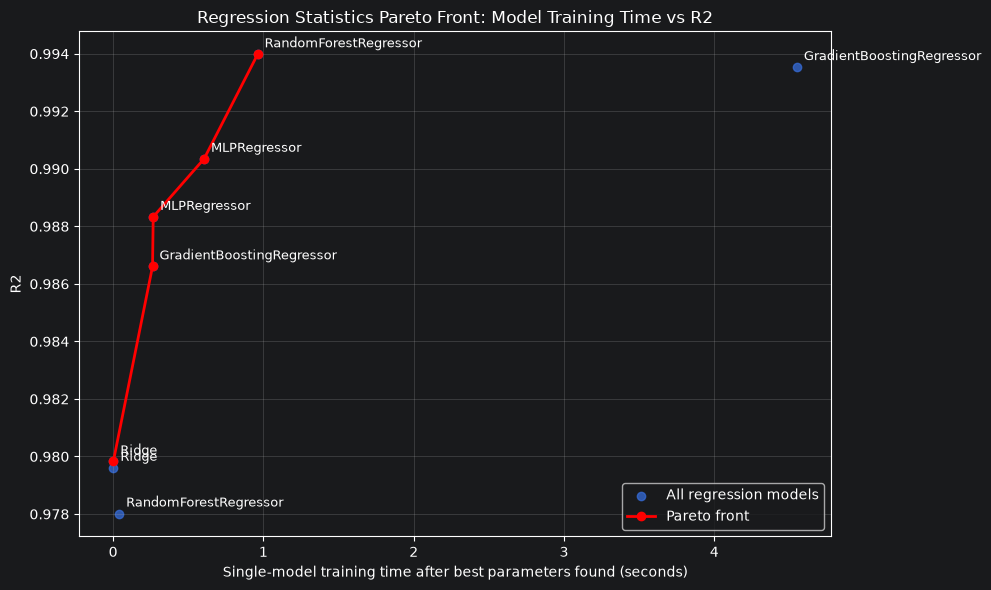

Regression statistics Pareto front, maximizing R2 while minimizing MSE:


,Task,Model,MSE,MAE,R2,Train Seconds,Best Params
0,Regression,RandomForestRegressor,1056.71758,18.74457,0.99398,0.961485,"{'max_depth': 24, 'min_samples_leaf': 1, 'n_es..."


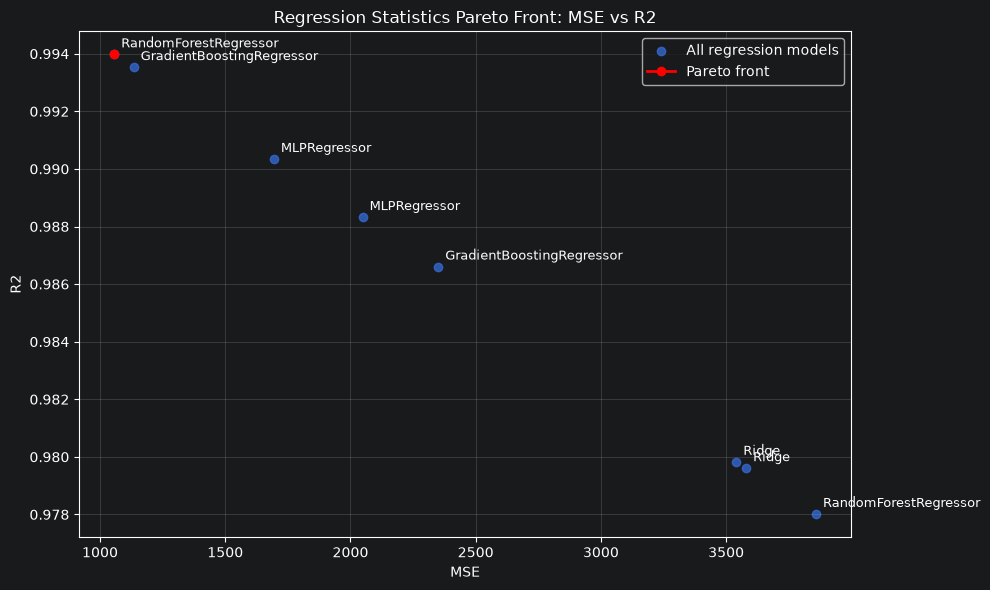

Classification model statistics:


,Task,Model,F1,Precision,Recall,Accuracy,Train Seconds,Best Params
0,Classification,RandomForestClassifier,0.943953,0.943921,0.944035,0.944035,0.226433,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es..."
1,Classification,GradientBoostingClassifier,0.943168,0.943171,0.943271,0.943271,11.566137,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
2,Classification,MLPClassifier,0.939080,0.939155,0.939201,0.939201,0.798462,"{'alpha': 0.001, 'hidden_layer_sizes': (50, 25..."
3,Classification,RandomForestClassifier,0.937197,0.937442,0.937166,0.937166,0.053294,"{'n_estimators': 10, 'max_depth': 7, 'min_samp..."
4,Classification,MLPClassifier,0.932555,0.933630,0.932842,0.932842,0.213758,"{'hidden_layer_sizes': (19,), 'alpha': 0.00124..."
5,Classification,GradientBoostingClassifier,0.922315,0.923741,0.922412,0.922412,0.365826,"{'n_estimators': 11, 'learning_rate': 0.078413..."


Classification statistics Pareto front, maximizing accuracy while minimizing single-model training time:


,Task,Model,F1,Precision,Recall,Accuracy,Train Seconds,Best Params
0,Classification,RandomForestClassifier,0.937197,0.937442,0.937166,0.937166,0.053294,"{'n_estimators': 10, 'max_depth': 7, 'min_samp..."
1,Classification,RandomForestClassifier,0.943953,0.943921,0.944035,0.944035,0.226433,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es..."


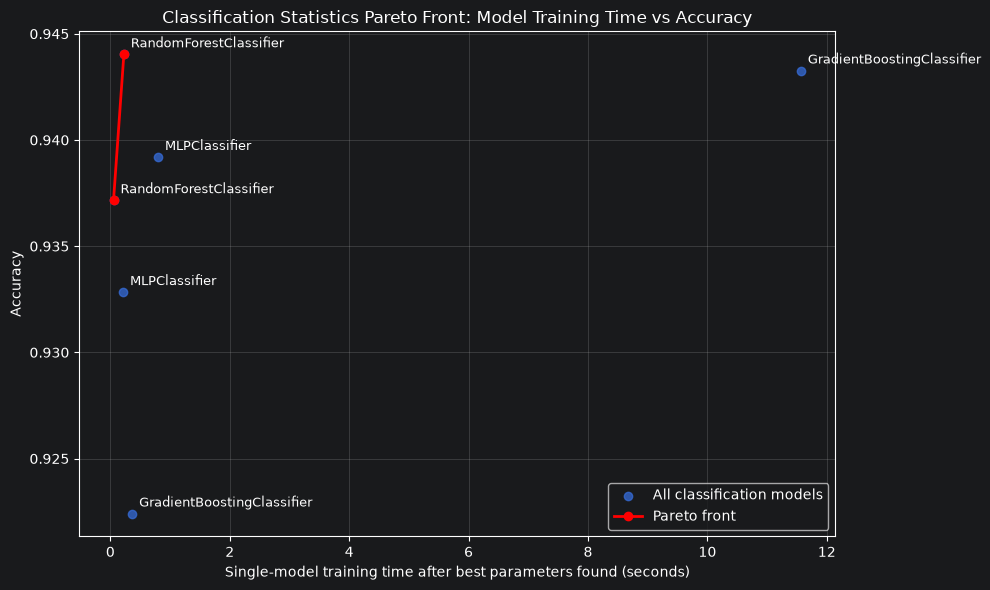

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, precision_score, recall_score


def regression_r2_mse_pareto_front(results_df, r2_column="R2", mse_column="MSE"):
    pareto_rows = []

    for _, candidate_row in results_df.iterrows():
        dominated = False

        for _, comparison_row in results_df.iterrows():
            is_at_least_as_good = (
                    comparison_row[r2_column] >= candidate_row[r2_column]
                    and comparison_row[mse_column] <= candidate_row[mse_column]
            )
            is_strictly_better = (
                    comparison_row[r2_column] > candidate_row[r2_column]
                    or comparison_row[mse_column] < candidate_row[mse_column]
            )

            if is_at_least_as_good and is_strictly_better:
                dominated = True
                break

        if not dominated:
            pareto_rows.append(candidate_row)

    return pd.DataFrame(pareto_rows).sort_values(
        by=[mse_column, r2_column],
        ascending=[True, False],
    ).reset_index(drop=True)


# Report the relevant stats for each trained regression model.
regression_stats = []
for _, row in regression_results_df.iterrows():
    estimator = row["Best Estimator"]
    y_pred = estimator.predict(X_test)

    regression_stats.append({
        "Task": "Regression",
        "Model": row["Model"],
        "MSE": mean_squared_error(y_reg_test, y_pred),
        "MAE": mean_absolute_error(y_reg_test, y_pred),
        "R2": r2_score(y_reg_test, y_pred),
        "Train Seconds": row["Train Seconds"],
        "Best Params": row["Best Params"],
    })

regression_stats_df = pd.DataFrame(regression_stats).sort_values(
    by=["R2", "Train Seconds"],
    ascending=[False, True],
).reset_index(drop=True)

regression_stats_pareto_front_df = pareto_front(regression_stats_df, "R2")
regression_stats_r2_mse_pareto_front_df = regression_r2_mse_pareto_front(regression_stats_df)

# Report the relevant stats for each trained classification model.
classification_stats = []
for _, row in classification_results_df.iterrows():
    estimator = row["Best Estimator"]
    y_pred = estimator.predict(X_test)

    classification_stats.append({
        "Task": "Classification",
        "Model": row["Model"],
        "F1": f1_score(y_cls_test, y_pred, average="weighted", zero_division=0),
        "Precision": precision_score(y_cls_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_cls_test, y_pred, average="weighted", zero_division=0),
        "Accuracy": accuracy_score(y_cls_test, y_pred),
        "Train Seconds": row["Train Seconds"],
        "Best Params": row["Best Params"],
    })

classification_stats_df = pd.DataFrame(classification_stats).sort_values(
    by=["Accuracy", "Train Seconds"],
    ascending=[False, True],
).reset_index(drop=True)

classification_stats_pareto_front_df = pareto_front(classification_stats_df, "Accuracy")

print("Regression model statistics:")
display(regression_stats_df)

print("Regression statistics Pareto front, maximizing R2 while minimizing single-model training time:")
display(regression_stats_pareto_front_df)

plt.figure(figsize=(10, 6))
plt.scatter(
    regression_stats_df["Train Seconds"],
    regression_stats_df["R2"],
    label="All regression models",
    alpha=0.75,
)

regression_stats_pareto_plot_df = regression_stats_pareto_front_df.sort_values("Train Seconds")
plt.plot(
    regression_stats_pareto_plot_df["Train Seconds"],
    regression_stats_pareto_plot_df["R2"],
    marker="o",
    linewidth=2,
    color="red",
    label="Pareto front",
)

for _, row in regression_stats_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Train Seconds"], row["R2"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

plt.xlabel("Single-model training time after best parameters found (seconds)")
plt.ylabel("R2")
plt.title("Regression Statistics Pareto Front: Model Training Time vs R2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Regression statistics Pareto front, maximizing R2 while minimizing MSE:")
display(regression_stats_r2_mse_pareto_front_df)

plt.figure(figsize=(10, 6))
plt.scatter(
    regression_stats_df["MSE"],
    regression_stats_df["R2"],
    label="All regression models",
    alpha=0.75,
)

regression_stats_r2_mse_pareto_plot_df = regression_stats_r2_mse_pareto_front_df.sort_values("MSE")
plt.plot(
    regression_stats_r2_mse_pareto_plot_df["MSE"],
    regression_stats_r2_mse_pareto_plot_df["R2"],
    marker="o",
    linewidth=2,
    color="red",
    label="Pareto front",
)

for _, row in regression_stats_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["MSE"], row["R2"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

plt.xlabel("MSE")
plt.ylabel("R2")
plt.title("Regression Statistics Pareto Front: MSE vs R2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Classification model statistics:")
display(classification_stats_df)

print("Classification statistics Pareto front, maximizing accuracy while minimizing single-model training time:")
display(classification_stats_pareto_front_df)

plt.figure(figsize=(10, 6))
plt.scatter(
    classification_stats_df["Train Seconds"],
    classification_stats_df["Accuracy"],
    label="All classification models",
    alpha=0.75,
)

classification_stats_pareto_plot_df = classification_stats_pareto_front_df.sort_values("Train Seconds")
plt.plot(
    classification_stats_pareto_plot_df["Train Seconds"],
    classification_stats_pareto_plot_df["Accuracy"],
    marker="o",
    linewidth=2,
    color="red",
    label="Pareto front",
)

for _, row in classification_stats_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Train Seconds"], row["Accuracy"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

plt.xlabel("Single-model training time after best parameters found (seconds)")
plt.ylabel("Accuracy")
plt.title("Classification Statistics Pareto Front: Model Training Time vs Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


There we go! Now we have a pareto front. `RandomForest` dominates as a function of overall accuracy. What I find fascinating is the pareto front of R2 vs MSE, where everything lies on a line. This is to be expected, since R2 and MSE are related by the equation R2 = 1 - (MSE / variance). That's not really a pareto front, so it can be ignored.

Additionally, ridge solver is the worst on accuracy, but it is by far the fastest to train. What surprised me is how Regression has a variance pareto front showing MLP and GradientBoost. I am suspicious that my DE algorithm (which I constrained for time) didn't _really_ find the best possible candidate, but I am skipping that for the sake of time.

## Unsupervised + Supervised Pipeline
Now it's time to cluster the training data using KMeans and then train regression and classification models on the clusters. I will only cluster based upon actual data features as opposed to the Classification Label which is binned (and would dominate the clustering artificially). 

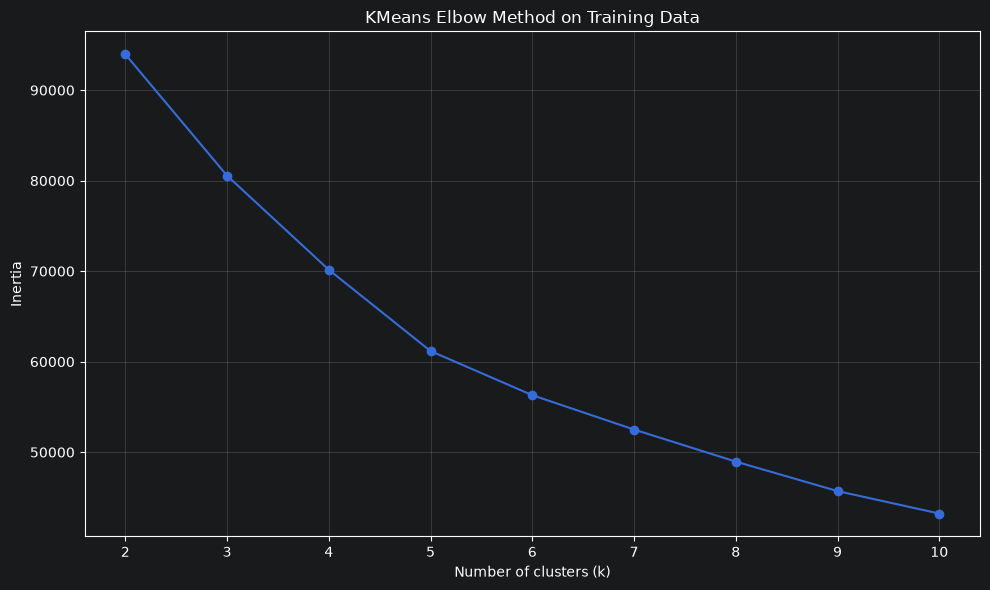

,k,Inertia,Silhouette Score
0,2,93961.882256,0.365641
1,3,80553.362162,0.225843
2,4,70154.992838,0.233609
3,5,61172.546996,0.247933
4,6,56296.375976,0.240199
5,7,52499.241225,0.199987
6,8,48955.712778,0.208813
7,9,45698.360372,0.211872
8,10,43219.069355,0.209594


Selected optimal number of clusters: 2


,Count,Regression_Label_Mean,Regression_Label_Std,Most_Common_Class
KMeans_Cluster,,,,
0,10988,440.630878,269.048626,100-240
1,4736,1055.883903,369.372379,1026-1600


,Task,Model,k,R2,MSE,MAE,Accuracy,F1,Precision,Recall
0,Regression with KMeans Cluster Feature,RandomForestRegressor,2,0.993996,1053.978594,18.738699,NaN,NaN,NaN,NaN
1,Classification with KMeans Cluster Feature,RandomForestClassifier,2,NaN,NaN,NaN,0.940982,0.940889,0.940897,0.940982


In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cluster only on training features to avoid label leakage.
k_values = range(2, 11)
kmeans_inertia = []
kmeans_silhouette_scores = []

for k in k_values:
    kmeans_candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    candidate_cluster_labels = kmeans_candidate.fit_predict(X_train)
    kmeans_inertia.append(kmeans_candidate.inertia_)
    kmeans_silhouette_scores.append(silhouette_score(X_train, candidate_cluster_labels))

plt.figure(figsize=(10, 6))
plt.plot(list(k_values), kmeans_inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Method on Training Data")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

kmeans_elbow_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": kmeans_inertia,
    "Silhouette Score": kmeans_silhouette_scores,
})

display(kmeans_elbow_df)

# Choose the cluster count with the best silhouette score after reviewing the elbow curve.
optimal_k = int(kmeans_elbow_df.loc[kmeans_elbow_df["Silhouette Score"].idxmax(), "k"])
print(f"Selected optimal number of clusters: {optimal_k}")

kmeans_model = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
X_train_cluster_labels = kmeans_model.fit_predict(X_train)
X_test_cluster_labels = kmeans_model.predict(X_test)

X_train_clustered = X_train.copy()
X_test_clustered = X_test.copy()

X_train_clustered["KMeans_Cluster"] = X_train_cluster_labels
X_test_clustered["KMeans_Cluster"] = X_test_cluster_labels

train_cluster_summary_df = pd.DataFrame({
    "KMeans_Cluster": X_train_cluster_labels,
    "Regression_Label": y_reg_train,
    "Classification_Label": y_cls_train,
}).groupby("KMeans_Cluster").agg(
    Count=("KMeans_Cluster", "size"),
    Regression_Label_Mean=("Regression_Label", "mean"),
    Regression_Label_Std=("Regression_Label", "std"),
    Most_Common_Class=("Classification_Label", lambda values: values.value_counts().idxmax()),
)

display(train_cluster_summary_df)

clustered_regression_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_regression_model["Best Params"],
)
clustered_regression_model.fit(X_train_clustered, y_reg_train)
clustered_y_reg_pred = clustered_regression_model.predict(X_test_clustered)

clustered_classification_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_classification_model["Best Params"],
)
clustered_classification_model.fit(X_train_clustered, y_cls_train)
clustered_y_cls_pred = clustered_classification_model.predict(X_test_clustered)

clustered_model_results_df = pd.DataFrame([
    {
        "Task": "Regression with KMeans Cluster Feature",
        "Model": "RandomForestRegressor",
        "k": optimal_k,
        "R2": r2_score(y_reg_test, clustered_y_reg_pred),
        "MSE": mean_squared_error(y_reg_test, clustered_y_reg_pred),
        "MAE": mean_absolute_error(y_reg_test, clustered_y_reg_pred),
    },
    {
        "Task": "Classification with KMeans Cluster Feature",
        "Model": "RandomForestClassifier",
        "k": optimal_k,
        "Accuracy": accuracy_score(y_cls_test, clustered_y_cls_pred),
        "F1": f1_score(y_cls_test, clustered_y_cls_pred, average="weighted", zero_division=0),
        "Precision": precision_score(y_cls_test, clustered_y_cls_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_cls_test, clustered_y_cls_pred, average="weighted", zero_division=0),
    },
])

display(clustered_model_results_df)


In [52]:
# !pip install git+https://github.com/fundthmcalculus/clustering
# Installing my own clustering library package.
# Plotting the data using my VAT/IVAT which is actually fast enough to handle a dataset of this size.
from clustering import VAT, IVAT

ModuleNotFoundError: No module named 'clustering'